# Approach V5: 3. Three-Phase Feature Selection
**Project:** Honeywell Predictive Alerting Project - Tag: `03TIC_1023.PV` (Threshold: 21.0 °C)

This notebook implements the client's new three-phase feature selection pipeline:
1. **Phase 1**: Distance Correlation analysis vs. target and pairwise between all features to isolate 5 dominant independent features.
2. **Phase 2**: SHAP feature selection trained on the less dominant features.
3. **Phase 3**: Lasso L1 regularization on the combined feature pool to select exactly 12 final features.

In [1]:
# Adjust working directory to project root if run from inside approch_v5 folder
import os
import sys
if os.path.basename(os.getcwd()) == 'approch_v5':
    os.chdir('..')
    print("Changed working directory to project root:", os.getcwd())
sys.path.append(os.path.join(os.getcwd(), 'approch_v5'))

Changed working directory to project root: D:\Python-2025\Antigravity\honeywell


In [2]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from feature_selection import distance_correlation_phase_1, shap_phase_2, lasso_phase_3

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load Data and Slice Train Split

In [3]:
df = pd.read_parquet("outputs/v5/candidate_features_pool.parquet")
print("Data loaded. Shape:", df.shape)
train_end = pd.to_datetime('2025-06-12 23:59:00')
train_df = df.loc[:train_end]
X_train = train_df.drop(columns=["03TIC_1023.PV"])
y_train = train_df["03TIC_1023.PV"]
print("Train split X shape:", X_train.shape, "y shape:", y_train.shape)

Data loaded. Shape: (2013380, 144)


Train split X shape: (1716314, 143) y shape: (1716314,)


## 2. Phase 1: Distance Correlation vs. Target & Pairwise

2026-07-23 09:15:05,139 - INFO - Executing Phase 1: Distance Correlation Analysis (vs. Target & Pairwise)...


C:\Users\Ajay_ML\miniconda3\Lib\site-packages\dcor\_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) array(int32, 1d, C), array(float64, 1d, C), bool. Rembember: only floating point values can be used in the compiled implementations.
  warnings.warn(


2026-07-23 09:15:06,280 - INFO - Distance Correlation Phase 1 completed.


2026-07-23 09:15:06,281 - INFO - Selected Dominant Features (kept aside): ['03TIC_1023.PV_lag_1', '03PIC_1023.PV_roll_mean_60', '03TIC_1023.PV_roll_min_60', '03TIC_1023.PV_lag_60', '03TI_1081.PV_lag_1']


2026-07-23 09:15:06,282 - INFO - Remaining Less Dominant Features: 138


C:\Users\Ajay_ML\AppData\Local\Temp\ipykernel_3468\1629805241.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=corr_df.head(20), x="Distance_Correlation", y="Feature", palette="Blues_r")


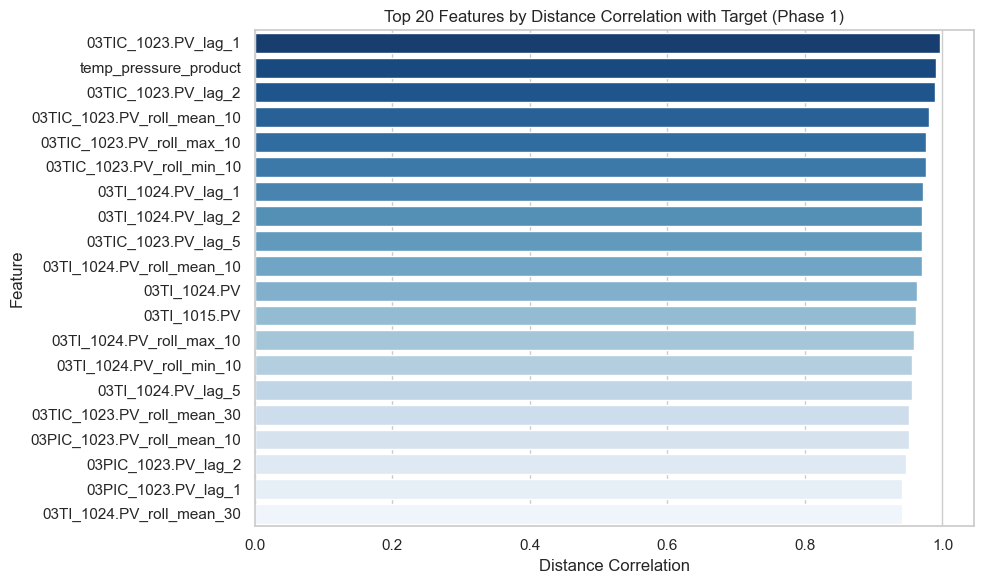

In [4]:
dominant_features, less_dominant_features, target_corrs = distance_correlation_phase_1(
    X_train, y_train, dominant_count=5, collinearity_threshold=0.90, sample_size=2000
)

# Plot top distance correlations with target
corr_df = pd.DataFrame(list(target_corrs.items()), columns=["Feature", "Distance_Correlation"]).sort_values(by="Distance_Correlation", ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=corr_df.head(20), x="Distance_Correlation", y="Feature", palette="Blues_r")
plt.title("Top 20 Features by Distance Correlation with Target (Phase 1)")
plt.xlabel("Distance Correlation")
plt.ylabel("Feature")
plt.tight_layout()
os.makedirs("approch_v5", exist_ok=True)
plt.savefig("approch_v5/distance_correlation_rankings.png", dpi=300)
plt.show()

### Pairwise Distance Correlation & Collinearity Filtering
To visualize the collinearity filtering process, we calculate the pairwise distance correlation matrix for the top 15 target-correlated features. Features are selected as dominant features if they are independent (pairwise distance correlation < 0.90 with already selected dominant features). Collinear features are skipped.

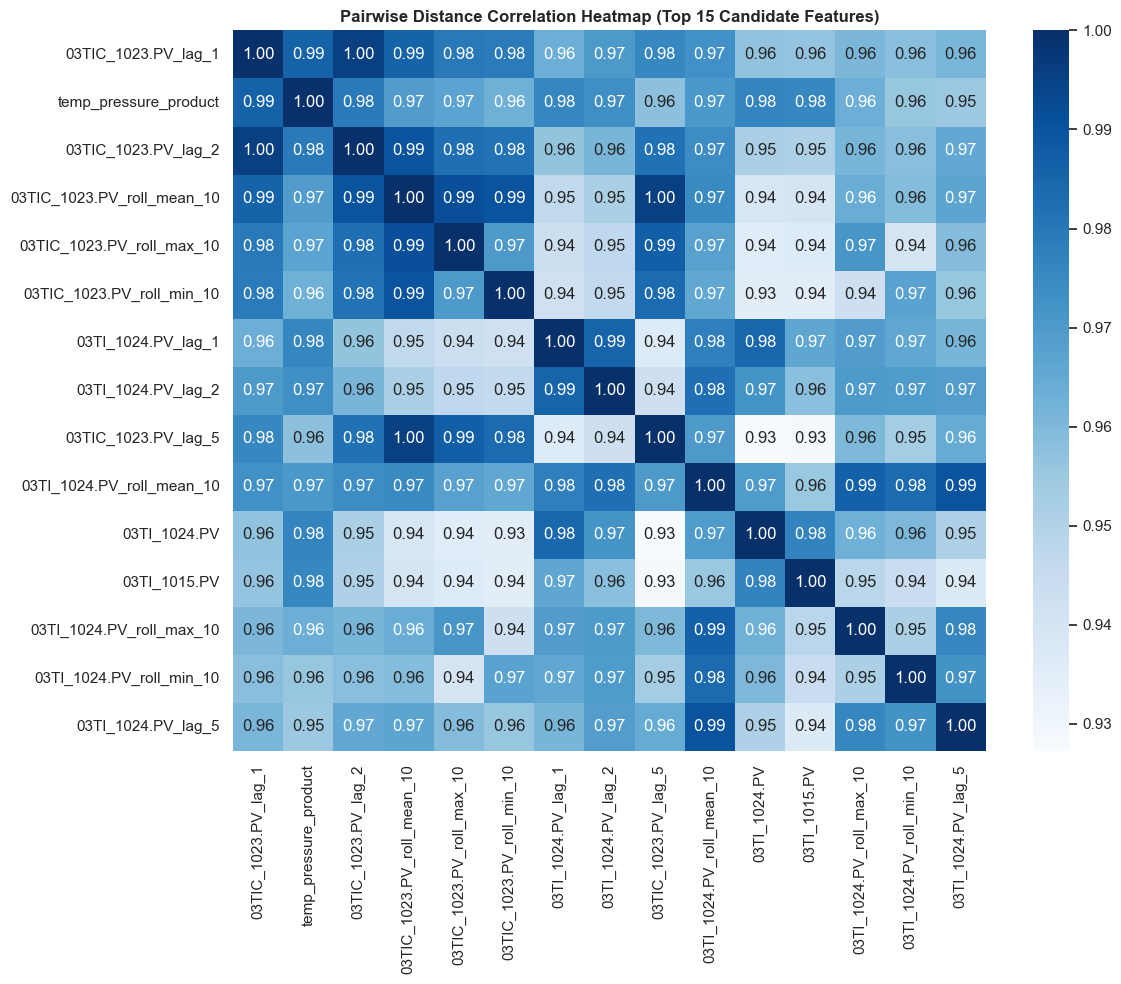

,Feature,Target DC,Status,Collinear With
0,03TIC_1023.PV_lag_1,0.996004,Selected (Dominant),-
1,temp_pressure_product,0.989993,Skipped (Collinear),03TIC_1023.PV_lag_1 (DC=0.9860)
2,03TIC_1023.PV_lag_2,0.989193,Skipped (Collinear),03TIC_1023.PV_lag_1 (DC=0.9957)
3,03TIC_1023.PV_roll_mean_10,0.980941,Skipped (Collinear),03TIC_1023.PV_lag_1 (DC=0.9858)
4,03TIC_1023.PV_roll_max_10,0.976087,Skipped (Collinear),03TIC_1023.PV_lag_1 (DC=0.9796)
5,03TIC_1023.PV_roll_min_10,0.975801,Skipped (Collinear),03TIC_1023.PV_lag_1 (DC=0.9791)
6,03TI_1024.PV_lag_1,0.971378,Skipped (Collinear),03TIC_1023.PV_lag_1 (DC=0.9635)
7,03TI_1024.PV_lag_2,0.970708,Skipped (Collinear),03TIC_1023.PV_lag_1 (DC=0.9704)
8,03TIC_1023.PV_lag_5,0.969743,Skipped (Collinear),03TIC_1023.PV_lag_1 (DC=0.9758)
9,03TI_1024.PV_roll_mean_10,0.969676,Skipped (Collinear),03TIC_1023.PV_lag_1 (DC=0.9728)


In [5]:
# Downsample to the same sample index to compute pairwise distance correlations
from dcor import distance_correlation
sample_idx = np.random.RandomState(42).choice(len(X_train), size=min(2000, len(X_train)), replace=False)
X_sample = X_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

# Get top 15 features by target correlation
sorted_features = sorted(target_corrs.items(), key=lambda x: x[1], reverse=True)
top_15_feats = [f[0] for f in sorted_features[:15]]

# Compute pairwise distance correlation matrix
p_corr_matrix = np.zeros((15, 15))
for i in range(15):
    for j in range(15):
        p_corr_matrix[i, j] = distance_correlation(X_sample[top_15_feats[i]].values, X_sample[top_15_feats[j]].values)

p_corr_df = pd.DataFrame(p_corr_matrix, index=top_15_feats, columns=top_15_feats)

# 1. Plot Pairwise Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(p_corr_df, annot=True, fmt=".2f", cmap="Blues", cbar=True)
plt.title("Pairwise Distance Correlation Heatmap (Top 15 Candidate Features)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("approch_v5/pairwise_distance_correlation_heatmap.png", dpi=300)
plt.show()

# 2. Build and Display Selection/Filtering Table
filtering_records = []
selected_dom = []
for feat in top_15_feats:
    collinear_with = None
    for dom in selected_dom:
        dist_corr = distance_correlation(X_sample[feat].values, X_sample[dom].values)
        if dist_corr > 0.90:
            collinear_with = f"{dom} (DC={dist_corr:.4f})"
            break
    if collinear_with is None and len(selected_dom) < 5:
        selected_dom.append(feat)
        filtering_records.append({"Feature": feat, "Target DC": target_corrs[feat], "Status": "Selected (Dominant)", "Collinear With": "-"})
    else:
        status_str = "Skipped (Collinear)" if collinear_with is not None else "Skipped (Limit Reached)"
        collinear_str = collinear_with if collinear_with is not None else "-"
        filtering_records.append({"Feature": feat, "Target DC": target_corrs[feat], "Status": status_str, "Collinear With": collinear_str})

filtering_df = pd.DataFrame(filtering_records)
import IPython.display as display
display.display(filtering_df)

## 3. Phase 2: SHAP Feature Selection on Less Dominant Features

2026-07-23 09:15:09,940 - INFO - Executing Phase 2: SHAP Feature Importance Filtering on Less Dominant Features...


2026-07-23 09:16:03,197 - INFO - SHAP Phase 2 completed. Kept 58 less dominant features using threshold 0.0001.


C:\Users\Ajay_ML\AppData\Local\Temp\ipykernel_3468\885278490.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shap_df.head(20), x="Mean_Abs_SHAP", y="Feature", palette="Oranges_r")


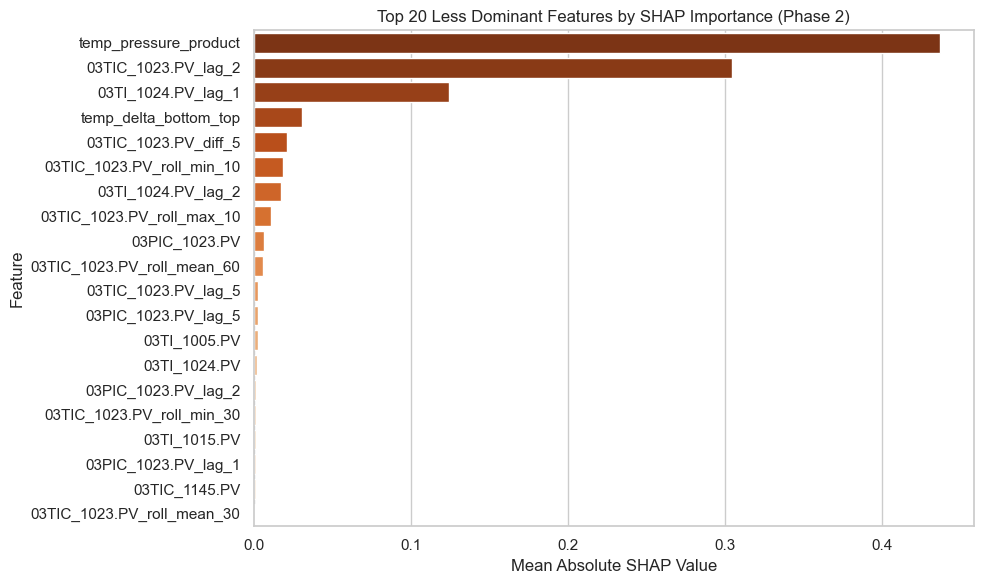

In [6]:
shap_selected, shap_df = shap_phase_2(X_train, y_train, less_dominant_features, threshold=1e-4, sample_size=5000)

# Plot top SHAP features
plt.figure(figsize=(10, 6))
sns.barplot(data=shap_df.head(20), x="Mean_Abs_SHAP", y="Feature", palette="Oranges_r")
plt.title("Top 20 Less Dominant Features by SHAP Importance (Phase 2)")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("approch_v5/shap_feature_importance.png", dpi=300)
plt.show()

## 4. Phase 3: Lasso L1 Regularization on Combined Feature Pool

2026-07-23 09:16:05,497 - INFO - Executing Phase 3: LassoCV L1 Regularization selection on combined features (Target: 12)...


Combined features pool size: 63


2026-07-23 09:22:39,841 - INFO - Phase 3 selection completed. Final 12 features selected.


Final selected 12 features: ['03TIC_1023.PV_lag_5', '03TI_1024.PV', '03TIC_1023.PV_diff_5', '03TIC_1023.PV_lag_1', '03TI_1024.PV_lag_1', 'temp_delta_bottom_top', '03TIC_1023.PV_roll_max_10', '03TIC_1023.PV_roll_min_10', '03PIC_1023.PV', 'temp_pressure_product', '03TI_1015.PV', '03TIC_1023.PV_roll_mean_60']


C:\Users\Ajay_ML\AppData\Local\Temp\ipykernel_3468\3462318490.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=active_coefs, x="Coefficient", y="Feature", palette="coolwarm")


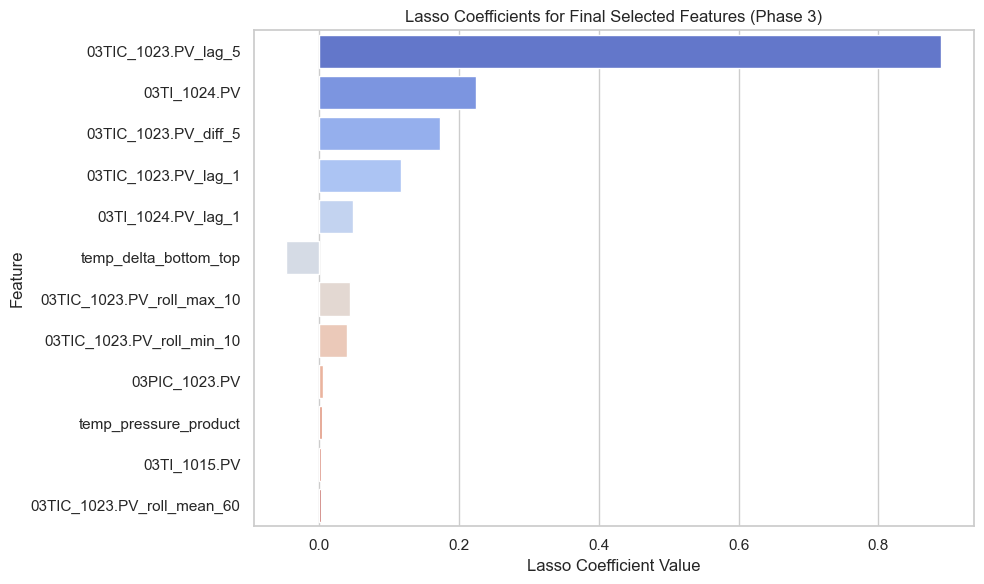

In [7]:
combined_features = dominant_features + shap_selected
print(f"Combined features pool size: {len(combined_features)}")

selected_features, coef_df = lasso_phase_3(X_train, y_train, combined_features, target_count=12)
print(f"Final selected 12 features: {selected_features}")

# Plot Lasso coefficients
active_coefs = coef_df[coef_df["Feature"].isin(selected_features)].copy()
plt.figure(figsize=(10, 6))
sns.barplot(data=active_coefs, x="Coefficient", y="Feature", palette="coolwarm")
plt.title("Lasso Coefficients for Final Selected Features (Phase 3)")
plt.xlabel("Lasso Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("approch_v5/lasso_coefficients.png", dpi=300)
plt.show()

## 5. Save Selected Features list

In [8]:
os.makedirs("models/v5", exist_ok=True)
with open("models/v5/selected_features_v5.pkl", "wb") as f:
    pickle.dump(selected_features, f)
print("Saved selected features to models/v5/selected_features_v5.pkl")

os.makedirs("approch_v5/models/v5", exist_ok=True)
with open("approch_v5/models/v5/selected_features_v5.pkl", "wb") as f:
    pickle.dump(selected_features, f)
print("Saved selected features to approch_v5/models/v5/selected_features_v5.pkl")

Saved selected features to models/v5/selected_features_v5.pkl
Saved selected features to approch_v5/models/v5/selected_features_v5.pkl
